In [1]:
!nvidia-smi

Fri Apr  3 10:35:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
import torch
import subprocess

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

print("\nCUDA_HOME:", os.environ.get("CUDA_HOME"))
print("\n/usr/local contents:")
!ls /usr/local | sed -n '1,40p'

Torch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4

CUDA_HOME: /usr/local/cuda

/usr/local contents:
bin
colab
cuda
cuda-12
cuda-12.8
dist_metrics.pxd
doc
etc
games
images
include
lib
libexec
LICENSE.md
man
nvidia
opt
sbin
share
src


In [ ]:
import os
import subprocess
from pathlib import Path

repo_dir = Path("/kaggle/working/nccl-tests")

if not repo_dir.exists():
    !git clone https://github.com/NVIDIA/nccl-tests.git /kaggle/working/nccl-tests

ret = subprocess.run(
    "cd /kaggle/working/nccl-tests && make -j",
    shell=True,
    text=True
)

# failed,check CUDA_HOME
if ret.returncode != 0:
    print("\nDefault build failed. Retrying with CUDA_HOME=/usr/local/cuda ...\n")
    ret = subprocess.run(
        "cd /kaggle/working/nccl-tests && make -j CUDA_HOME=/usr/local/cuda",
        shell=True,
        text=True
    )

if ret.returncode != 0:
    raise RuntimeError("nccl-tests build failed. Check the compiler / CUDA / NCCL environment.")

print("\nBuild finished.")
!ls /kaggle/working/nccl-tests/build | sed -n '1,50p'

In [4]:
# minimum sanity check
!cd /kaggle/working/nccl-tests/build && ./all_reduce_perf -b 8 -e 128M -f 2 -g 2

# nccl-tests version 2.18.2 nccl-headers=22501 nccl-library=22501
# Collective test starting: all_reduce_perf
# nThread 1 nGpus 2 minBytes 8 maxBytes 134217728 step: 2(factor) warmup iters: 1 iters: 20 agg iters: 1 validation: 1 graph: 0 unalign: 0
#
# Using devices
#  Rank  0 Group  0 Pid   1469 on 999d5ea371c5 device  0 [0000:00:04] Tesla T4
#  Rank  1 Group  0 Pid   1469 on 999d5ea371c5 device  1 [0000:00:05] Tesla T4
#
#                                                              out-of-place                       in-place          
#       size         count      type   redop    root     time   algbw   busbw  #wrong     time   algbw   busbw  #wrong 
#        (B)    (elements)                               (us)  (GB/s)  (GB/s)             (us)  (GB/s)  (GB/s)         
           8             2     float     sum      -1    16.04    0.00    0.00       0    15.79    0.00    0.00       0
          16             4     float     sum      -1    15.44    0.00    0.00       0    15.36   

In [6]:
import os
import subprocess
from pathlib import Path

LOG_DIR = Path("/kaggle/working/nccl_logs")
LOG_DIR.mkdir(parents=True, exist_ok=True)

def run_nccl_test(name, min_bytes, max_bytes, factor, gpus=2, extra_args=""):
    cmd = (
        f"cd /kaggle/working/nccl-tests/build && "
        f"./all_reduce_perf -b {min_bytes} -e {max_bytes} -f {factor} -g {gpus} {extra_args}"
    )
    log_path = LOG_DIR / f"{name}.txt"

    print(f"\n===== Running: {name} =====")
    print(cmd)
    print(f"Log => {log_path}\n")

    full_cmd = f"{cmd} | tee {log_path}"
    result = subprocess.run(full_cmd, shell=True, text=True)

    if result.returncode != 0:
        raise RuntimeError(f"Run failed for {name}")

    return str(log_path)

In [7]:
log_scan = run_nccl_test(
    name="allreduce_scan",
    min_bytes="8",
    max_bytes="256M",
    factor="2",
    gpus=2
)


===== Running: allreduce_scan =====
cd /kaggle/working/nccl-tests/build && ./all_reduce_perf -b 8 -e 256M -f 2 -g 2 
Log => /kaggle/working/nccl_logs/allreduce_scan.txt

# nccl-tests version 2.18.2 nccl-headers=22501 nccl-library=22501
# Collective test starting: all_reduce_perf
# nThread 1 nGpus 2 minBytes 8 maxBytes 268435456 step: 2(factor) warmup iters: 1 iters: 20 agg iters: 1 validation: 1 graph: 0 unalign: 0
#
# Using devices
#  Rank  0 Group  0 Pid   1502 on 999d5ea371c5 device  0 [0000:00:04] Tesla T4
#  Rank  1 Group  0 Pid   1502 on 999d5ea371c5 device  1 [0000:00:05] Tesla T4
#
#                                                              out-of-place                       in-place          
#       size         count      type   redop    root     time   algbw   busbw  #wrong     time   algbw   busbw  #wrong 
#        (B)    (elements)                               (us)  (GB/s)  (GB/s)             (us)  (GB/s)  (GB/s)         
           8             2     float     sum 

In [8]:
log_mid = run_nccl_test(
    name="allreduce_mid",
    min_bytes="1K",
    max_bytes="16M",
    factor="1.5",
    gpus=2
)


===== Running: allreduce_mid =====
cd /kaggle/working/nccl-tests/build && ./all_reduce_perf -b 1K -e 16M -f 1.5 -g 2 
Log => /kaggle/working/nccl_logs/allreduce_mid.txt

# nccl-tests version 2.18.2 nccl-headers=22501 nccl-library=22501
# Collective test starting: all_reduce_perf
# nThread 1 nGpus 2 minBytes 1024 maxBytes 16777216 step: 1048576(bytes) warmup iters: 1 iters: 20 agg iters: 1 validation: 1 graph: 0 unalign: 0
#
# Using devices
#  Rank  0 Group  0 Pid   1522 on 999d5ea371c5 device  0 [0000:00:04] Tesla T4
#  Rank  1 Group  0 Pid   1522 on 999d5ea371c5 device  1 [0000:00:05] Tesla T4
#
#                                                              out-of-place                       in-place          
#       size         count      type   redop    root     time   algbw   busbw  #wrong     time   algbw   busbw  #wrong 
#        (B)    (elements)                               (us)  (GB/s)  (GB/s)             (us)  (GB/s)  (GB/s)         
        1024           256     float  

In [9]:
log_large = run_nccl_test(
    name="allreduce_large",
    min_bytes="8M",
    max_bytes="512M",
    factor="2",
    gpus=2
)


===== Running: allreduce_large =====
cd /kaggle/working/nccl-tests/build && ./all_reduce_perf -b 8M -e 512M -f 2 -g 2 
Log => /kaggle/working/nccl_logs/allreduce_large.txt

# nccl-tests version 2.18.2 nccl-headers=22501 nccl-library=22501
# Collective test starting: all_reduce_perf
# nThread 1 nGpus 2 minBytes 8388608 maxBytes 536870912 step: 2(factor) warmup iters: 1 iters: 20 agg iters: 1 validation: 1 graph: 0 unalign: 0
#
# Using devices
#  Rank  0 Group  0 Pid   1542 on 999d5ea371c5 device  0 [0000:00:04] Tesla T4
#  Rank  1 Group  0 Pid   1542 on 999d5ea371c5 device  1 [0000:00:05] Tesla T4
#
#                                                              out-of-place                       in-place          
#       size         count      type   redop    root     time   algbw   busbw  #wrong     time   algbw   busbw  #wrong 
#        (B)    (elements)                               (us)  (GB/s)  (GB/s)             (us)  (GB/s)  (GB/s)         
     8388608       2097152     float

In [10]:
!ls -lh /kaggle/working/nccl_logs

total 12K
-rw-r--r-- 1 root root 1.7K Apr  3 10:44 allreduce_large.txt
-rw-r--r-- 1 root root 2.8K Apr  3 10:43 allreduce_mid.txt
-rw-r--r-- 1 root root 3.9K Apr  3 10:43 allreduce_scan.txt


In [11]:
import re
import pandas as pd
from pathlib import Path

def parse_nccl_log(log_path, test_name=None):
    log_path = Path(log_path)
    rows = []

    # Common data rows usually start with a numeric message size.
    # Example:
    # 8 2 float sum ... time algbw busbw errors
    #
    # The exact number of columns may vary slightly across versions,
    # so this parser uses a more tolerant strategy.
    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue

            # Skip lines that are clearly not data rows.
            if s.startswith("#") or s.startswith("nThread") or s.startswith("Out of bounds"):
                continue

            # Only keep lines that begin with a digit.
            if not re.match(r"^\d+", s):
                continue

            parts = re.split(r"\s+", s)

            # Try to stay compatible with common output formats.
            # The leading columns are often something like:
            # size / count / type / op / root / time / algbw / busbw / error
            # Instead of assuming a strict fixed layout, keep the raw split first.
            row = {
                "test_name": test_name or log_path.stem,
                "raw_line": s,
                "n_cols": len(parts)
            }

            # Try to read the most common leading fields.
            # Typical early columns:
            # 0:size  1:count  2:type  3:redop ...
            try:
                row["size_bytes"] = int(parts[0])
            except:
                row["size_bytes"] = None

            try:
                row["count"] = int(parts[1])
            except:
                row["count"] = None

            row["dtype"] = parts[2] if len(parts) > 2 else None
            row["op"] = parts[3] if len(parts) > 3 else None

            # Collect all numeric tokens from the row.
            # In many versions, values near the end include:
            # time / algbw / busbw / wrong
            numeric_vals = []
            for p in parts:
                try:
                    numeric_vals.append(float(p))
                except:
                    pass

            row["numeric_values"] = numeric_vals

            # A more robust fallback is to inspect the trailing fields directly.
            # In many versions, the last columns may contain:
            # time / algbw / busbw / #wrong
            # This is only a best-effort parse.
            # If column positions differ, raw_line can still be used for manual re-parsing.
            try:
                row["wrong"] = int(parts[-1])
            except:
                row["wrong"] = None

            # Try to interpret the last 3 floating-point values
            # as candidate time / algbw / busbw fields.
            tail_floats = []
            for p in parts[::-1]:
                try:
                    tail_floats.append(float(p))
                except:
                    if len(tail_floats) >= 3:
                        break

            tail_floats = tail_floats[:3][::-1]  # reverse back to original order
            if len(tail_floats) == 3:
                row["time_candidate"] = tail_floats[0]
                row["algbw_candidate"] = tail_floats[1]
                row["busbw_candidate"] = tail_floats[2]
            else:
                row["time_candidate"] = None
                row["algbw_candidate"] = None
                row["busbw_candidate"] = None

            rows.append(row)

    return pd.DataFrame(rows)

df_scan = parse_nccl_log(log_scan, "allreduce_scan")
df_mid = parse_nccl_log(log_mid, "allreduce_mid")
df_large = parse_nccl_log(log_large, "allreduce_large")

df_all = pd.concat([df_scan, df_mid, df_large], ignore_index=True)
df_all.head(20)

,test_name,raw_line,n_cols,size_bytes,count,dtype,op,numeric_values,wrong,time_candidate,algbw_candidate,busbw_candidate
0,allreduce_scan,8 2 float sum -1 1...,13,8,2,float,sum,"[8.0, 2.0, -1.0, 14.32, 0.0, 0.0, 0.0, 14.46, ...",0,0.00,0.00,0.0
1,allreduce_scan,16 4 float sum -1 ...,13,16,4,float,sum,"[16.0, 4.0, -1.0, 19.34, 0.0, 0.0, 0.0, 13.99,...",0,0.00,0.00,0.0
2,allreduce_scan,32 8 float sum -1 ...,13,32,8,float,sum,"[32.0, 8.0, -1.0, 19.11, 0.0, 0.0, 0.0, 15.72,...",0,0.00,0.00,0.0
3,allreduce_scan,64 16 float sum -1 ...,13,64,16,float,sum,"[64.0, 16.0, -1.0, 20.54, 0.0, 0.0, 0.0, 15.56...",0,0.00,0.00,0.0
4,allreduce_scan,128 32 float sum -1 ...,13,128,32,float,sum,"[128.0, 32.0, -1.0, 19.69, 0.01, 0.01, 0.0, 15...",0,0.01,0.01,0.0
5,allreduce_scan,256 64 float sum -1 ...,13,256,64,float,sum,"[256.0, 64.0, -1.0, 19.78, 0.01, 0.01, 0.0, 15...",0,0.02,0.02,0.0
6,allreduce_scan,512 128 float sum -1 ...,13,512,128,float,sum,"[512.0, 128.0, -1.0, 17.88, 0.03, 0.03, 0.0, 1...",0,0.04,0.04,0.0
7,allreduce_scan,1024 256 float sum -1 ...,13,1024,256,float,sum,"[1024.0, 256.0, -1.0, 16.76, 0.06, 0.06, 0.0, ...",0,0.07,0.07,0.0
8,allreduce_scan,2048 512 float sum -1 ...,13,2048,512,float,sum,"[2048.0, 512.0, -1.0, 17.12, 0.12, 0.12, 0.0, ...",0,0.16,0.16,0.0
9,allreduce_scan,4096 1024 float sum -1 ...,13,4096,1024,float,sum,"[4096.0, 1024.0, -1.0, 23.24, 0.18, 0.18, 0.0,...",0,0.30,0.30,0.0


In [12]:
df_view = df_all[[
    "test_name",
    "size_bytes",
    "count",
    "dtype",
    "op",
    "time_candidate",
    "algbw_candidate",
    "busbw_candidate",
    "wrong",
    "raw_line"
]].copy()

df_view = df_view.sort_values(["test_name", "size_bytes"], ascending=[True, True]).reset_index(drop=True)
df_view.head(50)

,test_name,size_bytes,count,dtype,op,time_candidate,algbw_candidate,busbw_candidate,wrong,raw_line
0,allreduce_large,8388608,2097152,float,sum,3.99,3.99,0.0,0,8388608 2097152 float sum -...
1,allreduce_large,16777216,4194304,float,sum,4.01,4.01,0.0,0,16777216 4194304 float sum ...
2,allreduce_large,33554432,8388608,float,sum,4.02,4.02,0.0,0,33554432 8388608 float sum ...
3,allreduce_large,67108864,16777216,float,sum,4.03,4.03,0.0,0,67108864 16777216 float sum ...
4,allreduce_large,134217728,33554432,float,sum,4.03,4.03,0.0,0,134217728 33554432 float sum ...
5,allreduce_large,268435456,67108864,float,sum,4.03,4.03,0.0,0,268435456 67108864 float sum ...
6,allreduce_large,536870912,134217728,float,sum,4.03,4.03,0.0,0,536870912 134217728 float sum ...
7,allreduce_mid,1024,256,float,sum,0.06,0.06,0.0,0,1024 256 float sum -1 ...
8,allreduce_mid,1049600,262400,float,sum,3.30,3.30,0.0,0,1049600 262400 float sum -...
9,allreduce_mid,2098176,524544,float,sum,3.66,3.66,0.0,0,2098176 524544 float sum -...


In [13]:
def human_bytes(n):
    if pd.isna(n):
        return None
    n = float(n)
    units = ["B", "KB", "MB", "GB"]
    i = 0
    while n >= 1024 and i < len(units)-1:
        n /= 1024
        i += 1
    return f"{n:.2f} {units[i]}"

df_view["size_human"] = df_view["size_bytes"].apply(human_bytes)

cols = [
    "test_name",
    "size_bytes",
    "size_human",
    "count",
    "dtype",
    "op",
    "time_candidate",
    "algbw_candidate",
    "busbw_candidate",
    "wrong"
]
df_pretty = df_view[cols].copy()
df_pretty.head(10)

,test_name,size_bytes,size_human,count,dtype,op,time_candidate,algbw_candidate,busbw_candidate,wrong
0,allreduce_large,8388608,8.00 MB,2097152,float,sum,3.99,3.99,0.0,0
1,allreduce_large,16777216,16.00 MB,4194304,float,sum,4.01,4.01,0.0,0
2,allreduce_large,33554432,32.00 MB,8388608,float,sum,4.02,4.02,0.0,0
3,allreduce_large,67108864,64.00 MB,16777216,float,sum,4.03,4.03,0.0,0
4,allreduce_large,134217728,128.00 MB,33554432,float,sum,4.03,4.03,0.0,0
5,allreduce_large,268435456,256.00 MB,67108864,float,sum,4.03,4.03,0.0,0
6,allreduce_large,536870912,512.00 MB,134217728,float,sum,4.03,4.03,0.0,0
7,allreduce_mid,1024,1.00 KB,256,float,sum,0.06,0.06,0.0,0
8,allreduce_mid,1049600,1.00 MB,262400,float,sum,3.30,3.30,0.0,0
9,allreduce_mid,2098176,2.00 MB,524544,float,sum,3.66,3.66,0.0,0


In [14]:
csv_path = "/kaggle/working/allreduce_day1_results.csv"
df_pretty.to_csv(csv_path, index=False)
print("Saved:", csv_path)

Saved: /kaggle/working/allreduce_day1_results.csv


In [15]:
targets = [
    8,
    1024,
    64 * 1024,
    4 * 1024 * 1024,
    64 * 1024 * 1024,
    256 * 1024 * 1024,
]

summary_rows = []
for test_name in df_pretty["test_name"].dropna().unique():
    sub = df_pretty[df_pretty["test_name"] == test_name].copy()
    if sub.empty:
        continue
    for t in targets:
        sub2 = sub.dropna(subset=["size_bytes"]).copy()
        if sub2.empty:
            continue
        idx = (sub2["size_bytes"] - t).abs().idxmin()
        summary_rows.append(sub2.loc[idx])

df_summary = pd.DataFrame(summary_rows).drop_duplicates(subset=["test_name", "size_bytes"])
df_summary = df_summary.sort_values(["test_name", "size_bytes"]).reset_index(drop=True)
df_summary

,test_name,size_bytes,size_human,count,dtype,op,time_candidate,algbw_candidate,busbw_candidate,wrong
0,allreduce_large,8388608,8.00 MB,2097152,float,sum,3.99,3.99,0.0,0
1,allreduce_large,67108864,64.00 MB,16777216,float,sum,4.03,4.03,0.0,0
2,allreduce_large,268435456,256.00 MB,67108864,float,sum,4.03,4.03,0.0,0
3,allreduce_mid,1024,1.00 KB,256,float,sum,0.06,0.06,0.0,0
4,allreduce_mid,4195328,4.00 MB,1048832,float,sum,3.87,3.87,0.0,0
5,allreduce_mid,15729664,15.00 MB,3932416,float,sum,3.96,3.96,0.0,0
6,allreduce_scan,8,8.00 B,2,float,sum,0.00,0.00,0.0,0
7,allreduce_scan,1024,1.00 KB,256,float,sum,0.07,0.07,0.0,0
8,allreduce_scan,65536,64.00 KB,16384,float,sum,1.47,1.47,0.0,0
9,allreduce_scan,4194304,4.00 MB,1048576,float,sum,3.88,3.88,0.0,0


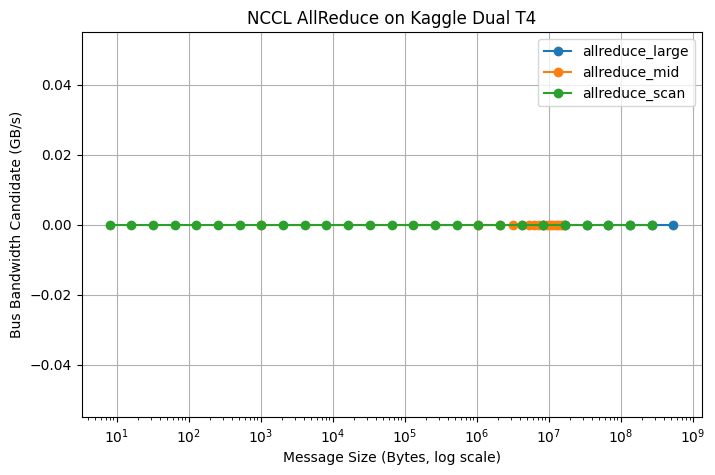

In [16]:
import matplotlib.pyplot as plt

plot_df = df_pretty.dropna(subset=["size_bytes", "busbw_candidate"]).copy()

plt.figure(figsize=(8,5))
for test_name, sub in plot_df.groupby("test_name"):
    sub = sub.sort_values("size_bytes")
    plt.plot(sub["size_bytes"], sub["busbw_candidate"], marker="o", label=test_name)

plt.xscale("log")
plt.xlabel("Message Size (Bytes, log scale)")
plt.ylabel("Bus Bandwidth Candidate (GB/s)")
plt.title("NCCL AllReduce on Kaggle Dual T4")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
print(open(log_scan, "r").read().splitlines()[:40])

['# nccl-tests version 2.18.2 nccl-headers=22501 nccl-library=22501', '# Collective test starting: all_reduce_perf', '# nThread 1 nGpus 2 minBytes 8 maxBytes 268435456 step: 2(factor) warmup iters: 1 iters: 20 agg iters: 1 validation: 1 graph: 0 unalign: 0', '#', '# Using devices', '#  Rank  0 Group  0 Pid   1502 on 999d5ea371c5 device  0 [0000:00:04] Tesla T4', '#  Rank  1 Group  0 Pid   1502 on 999d5ea371c5 device  1 [0000:00:05] Tesla T4', '#', '#                                                              out-of-place                       in-place          ', '#       size         count      type   redop    root     time   algbw   busbw  #wrong     time   algbw   busbw  #wrong ', '#        (B)    (elements)                               (us)  (GB/s)  (GB/s)             (us)  (GB/s)  (GB/s)         ', '           8             2     float     sum      -1    14.32    0.00    0.00       0    14.46    0.00    0.00       0', '          16             4     float     sum      -1    19.

In [18]:
import re
import pandas as pd
from pathlib import Path

def parse_nccl_log_strict(log_path, test_name=None):
    log_path = Path(log_path)
    rows = []

    header = None
    col_idx = {}

    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue

            # Find the real table header
            if "algbw" in s.lower() and "busbw" in s.lower():
                header = re.split(r"\s+", s.lstrip("# ").strip())
                col_idx = {name.lower(): i for i, name in enumerate(header)}
                print("Detected header:", header)
                continue

            # Skip until header is found
            if header is None:
                continue

            # Keep only rows starting with a number
            if not re.match(r"^\d+", s):
                continue

            parts = re.split(r"\s+", s)

            # Skip malformed rows
            if len(parts) < len(header) - 2:
                continue

            row = {
                "test_name": test_name or log_path.stem,
                "raw_line": s,
            }

            def get_col(*names):
                for name in names:
                    if name.lower() in col_idx and col_idx[name.lower()] < len(parts):
                        return parts[col_idx[name.lower()]]
                return None

            def to_int(x):
                try:
                    return int(x)
                except:
                    return None

            def to_float(x):
                try:
                    return float(x)
                except:
                    return None

            row["size_bytes"] = to_int(get_col("size", "bytes"))
            row["count"] = to_int(get_col("count", "n"))
            row["dtype"] = get_col("type", "datatype")
            row["op"] = get_col("op", "redop")
            row["time_us"] = to_float(get_col("time", "time(us)", "us"))
            row["algbw"] = to_float(get_col("algbw"))
            row["busbw"] = to_float(get_col("busbw"))
            row["wrong"] = to_int(get_col("wrong", "#wrong", "errors"))

            rows.append(row)

    return pd.DataFrame(rows)

In [19]:
df_scan = parse_nccl_log_strict(log_scan, "allreduce_scan")
df_mid = parse_nccl_log_strict(log_mid, "allreduce_mid")
df_large = parse_nccl_log_strict(log_large, "allreduce_large")

df_all = pd.concat([df_scan, df_mid, df_large], ignore_index=True)
df_all.head(20)

Detected header: ['size', 'count', 'type', 'redop', 'root', 'time', 'algbw', 'busbw', '#wrong', 'time', 'algbw', 'busbw', '#wrong']
Detected header: ['size', 'count', 'type', 'redop', 'root', 'time', 'algbw', 'busbw', '#wrong', 'time', 'algbw', 'busbw', '#wrong']
Detected header: ['size', 'count', 'type', 'redop', 'root', 'time', 'algbw', 'busbw', '#wrong', 'time', 'algbw', 'busbw', '#wrong']


,test_name,raw_line,size_bytes,count,dtype,op,time_us,algbw,busbw,wrong
0,allreduce_scan,8 2 float sum -1 1...,8,2,float,sum,14.46,0.00,0.00,0
1,allreduce_scan,16 4 float sum -1 ...,16,4,float,sum,13.99,0.00,0.00,0
2,allreduce_scan,32 8 float sum -1 ...,32,8,float,sum,15.72,0.00,0.00,0
3,allreduce_scan,64 16 float sum -1 ...,64,16,float,sum,15.56,0.00,0.00,0
4,allreduce_scan,128 32 float sum -1 ...,128,32,float,sum,15.74,0.01,0.01,0
5,allreduce_scan,256 64 float sum -1 ...,256,64,float,sum,15.68,0.02,0.02,0
6,allreduce_scan,512 128 float sum -1 ...,512,128,float,sum,12.56,0.04,0.04,0
7,allreduce_scan,1024 256 float sum -1 ...,1024,256,float,sum,14.34,0.07,0.07,0
8,allreduce_scan,2048 512 float sum -1 ...,2048,512,float,sum,12.51,0.16,0.16,0
9,allreduce_scan,4096 1024 float sum -1 ...,4096,1024,float,sum,13.46,0.30,0.30,0


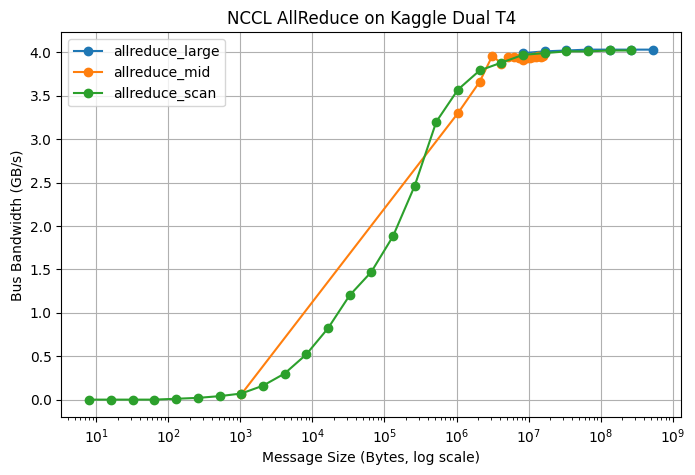

In [20]:
import matplotlib.pyplot as plt

plot_df = df_all.dropna(subset=["size_bytes", "busbw"]).copy()

plt.figure(figsize=(8,5))
for test_name, sub in plot_df.groupby("test_name"):
    sub = sub.sort_values("size_bytes")
    plt.plot(sub["size_bytes"], sub["busbw"], marker="o", label=test_name)

plt.xscale("log")
plt.xlabel("Message Size (Bytes, log scale)")
plt.ylabel("Bus Bandwidth (GB/s)")
plt.title("NCCL AllReduce on Kaggle Dual T4")
plt.legend()
plt.grid(True)
plt.show()

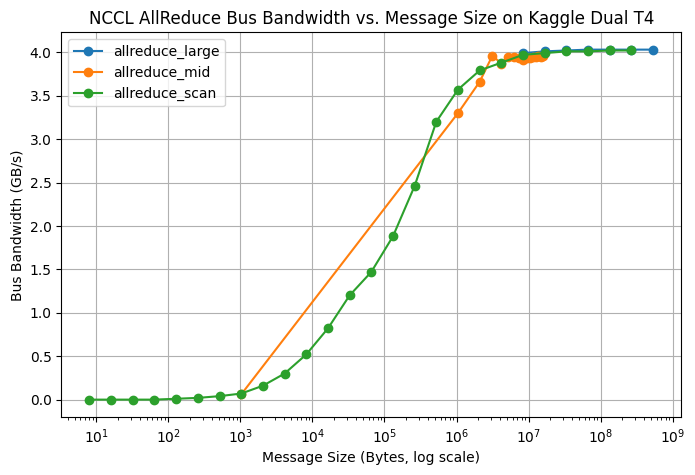

In [21]:
import matplotlib.pyplot as plt

plot_df = df_all.dropna(subset=["size_bytes", "busbw"]).copy()

plt.figure(figsize=(8,5))
for test_name, sub in sorted(plot_df.groupby("test_name"), key=lambda x: x[0]):
    sub = sub.sort_values("size_bytes")
    plt.plot(sub["size_bytes"], sub["busbw"], marker="o", label=test_name)

plt.xscale("log")
plt.xlabel("Message Size (Bytes, log scale)")
plt.ylabel("Bus Bandwidth (GB/s)")
plt.title("NCCL AllReduce Bus Bandwidth vs. Message Size on Kaggle Dual T4")
plt.legend()
plt.grid(True)
plt.show()

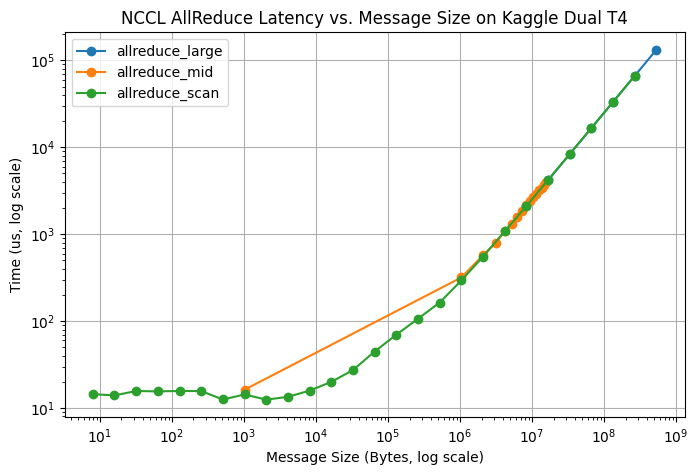

In [22]:
plt.figure(figsize=(8,5))
for test_name, sub in sorted(df_all.groupby("test_name"), key=lambda x: x[0]):
    sub = sub.dropna(subset=["size_bytes", "time_us"]).sort_values("size_bytes")
    plt.plot(sub["size_bytes"], sub["time_us"], marker="o", label=test_name)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Message Size (Bytes, log scale)")
plt.ylabel("Time (us, log scale)")
plt.title("NCCL AllReduce Latency vs. Message Size on Kaggle Dual T4")
plt.legend()
plt.grid(True)
plt.show()